In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [2]:
heart_data=pd.read_csv('../input/heart-disease-uci/heart.csv')
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Data contains; 

age - age in years 

sex - (1 = male; 0 = female) 

cp - chest pain type 

trestbps - resting blood pressure (in mm Hg on admission to the hospital) 

chol - serum cholestoral in mg/dl 

fbs - (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false) 

restecg - resting electrocardiographic results 

thalach - maximum heart rate achieved 

exang - exercise induced angina (1 = yes; 0 = no) 

oldpeak - ST depression induced by exercise relative to rest 

slope - the slope of the peak exercise ST segment 

ca - number of major vessels (0-3) colored by flourosopy 

thal - 3 = normal; 6 = fixed defect; 7 = reversable defect 

target - have disease or not (1=yes, 0=no)


In [3]:
cat_col=['cp','fbs','exang','thal']
num_col=['trestbps','chol','restecg','thalach','oldpeak','slope']

<AxesSubplot:xlabel='target'>

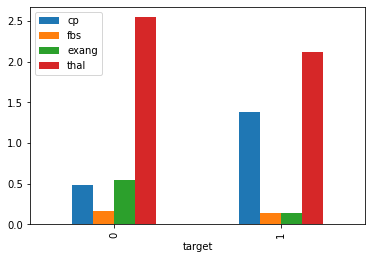

In [4]:
heart_data.groupby('target').mean()[cat_col].plot(kind='bar')

<AxesSubplot:xlabel='target'>

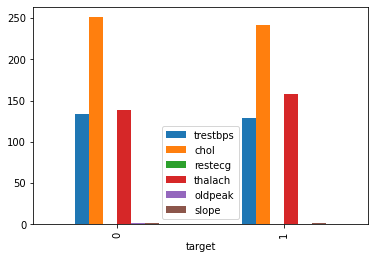

In [5]:
heart_data.groupby('target').mean()[num_col].plot(kind='bar')

In [6]:
heart_data[['restecg']].value_counts()

restecg
1          152
0          147
2            4
dtype: int64

In [7]:
heart_data.value_counts()

age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  target
38   1    2   138       175   0    1        173      0      0.0      2      4   2     1         2
59   1    0   110       239   0    0        142      1      1.2      1      1   3     0         1
          2   126       218   1    1        134      0      2.2      1      1   1     0         1
          1   140       221   0    1        164      1      0.0      2      0   2     1         1
          0   170       326   0    0        140      1      3.4      0      0   3     0         1
                                                                                               ..
51   1    2   94        227   0    1        154      1      0.0      2      1   3     1         1
          0   140       299   0    1        173      1      1.6      2      0   3     0         1
                        298   0    1        122      1      4.2      1      3   3     0         1
                        2

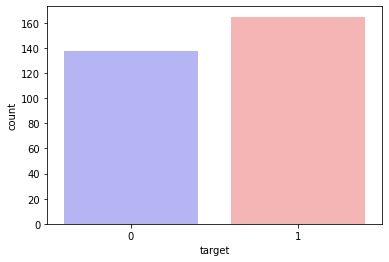

In [8]:
#Check the balanced of the dataset
sns.countplot(x="target", data=heart_data, palette="bwr")
plt.show()

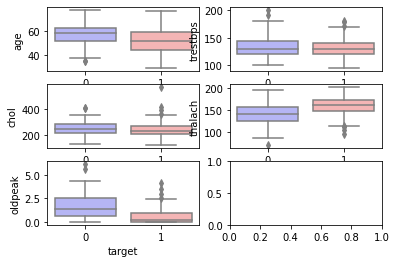

In [9]:
fig, axs = plt.subplots(nrows=3, ncols=2)
sns.boxplot(x="target",y='age',data=heart_data, palette="bwr",ax=axs[0,0])
sns.boxplot(x="target",y='trestbps',data=heart_data, palette="bwr",ax=axs[0,1])
sns.boxplot(x="target",y='chol',data=heart_data, palette="bwr",ax=axs[1,0])
sns.boxplot(x="target",y='thalach',data=heart_data, palette="bwr",ax=axs[1,1])
sns.boxplot(x="target",y='oldpeak',data=heart_data, palette="bwr",ax=axs[2,0])
plt.show()

# Testing

In [10]:
mean_data=heart_data.groupby('target').mean()[['age','thalach','oldpeak','chol','trestbps']]
mean_data

,age,thalach,oldpeak,chol,trestbps
target,,,,,
0,56.601449,139.101449,1.585507,251.086957,134.398551
1,52.496970,158.466667,0.583030,242.230303,129.303030


In [11]:
std_data=heart_data.groupby('target').std()[['age','thalach','oldpeak','chol','trestbps']]
std_data

,age,thalach,oldpeak,chol,trestbps
target,,,,,
0,7.962082,22.598782,1.300340,49.454614,18.729944
1,9.550651,19.174276,0.780683,53.552872,16.169613


In [12]:
count_data=heart_data.groupby('target').count()[['age','thalach','oldpeak','chol']]
count_data

,age,thalach,oldpeak,chol
target,,,,
0,138,138,138,138
1,165,165,165,165


In [13]:
Sp=((std_data**2).loc[0]*(138-1)+(std_data**2).loc[1]*(165-1))/(138+165-2)
Sp

age           78.552585
thalach      432.762945
oldpeak        1.101673
chol        2675.768123
trestbps     302.126007
dtype: float64

In [14]:
(mean_data.loc[1]-mean_data.loc[0])/((Sp*(1/138+1/165))**(1/2))

age        -4.014561
thalach     8.069703
oldpeak    -8.279580
chol       -1.484245
trestbps   -2.541293
dtype: float64

# EDA

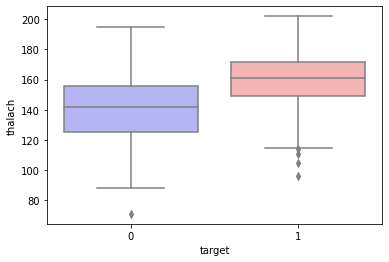

In [15]:
sns.boxplot(x="target",y='thalach',data=heart_data, palette="bwr")
plt.show()

In [16]:
#Implied the mean in each categories
mean_data=heart_data.groupby('target').mean()
mean_data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
target,,,,,,,,,,,,,
0,56.601449,0.826087,0.478261,134.398551,251.086957,0.159420,0.449275,139.101449,0.550725,1.585507,1.166667,1.166667,2.543478
1,52.496970,0.563636,1.375758,129.303030,242.230303,0.139394,0.593939,158.466667,0.139394,0.583030,1.593939,0.363636,2.121212


In [17]:
heart_data=heart_data.drop(['trestbps','chol','fbs'],axis=1)

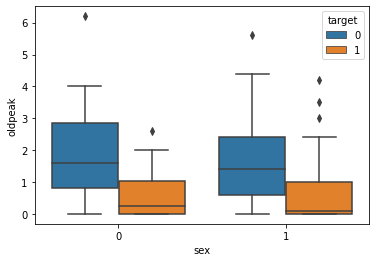

In [18]:
sns.boxplot(x='sex',y='oldpeak',hue='target',data=heart_data)
plt.show()

In [19]:
heart_data.describe()

,age,sex,cp,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [20]:
#The higher the age the higher chance of defect
heart_data['AgeBand'] = pd.cut(heart_data['age'], 3)

In [21]:
heart_data[['AgeBand', 'target']].groupby(['AgeBand'], as_index=False).mean().sort_values(by='AgeBand', ascending=True)

,AgeBand,target
0,"(28.952, 45.0]",0.750000
1,"(45.0, 61.0]",0.494048
2,"(61.0, 77.0]",0.478873


In [22]:
heart_data.columns

Index(['age', 'sex', 'cp', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope',
       'ca', 'thal', 'target', 'AgeBand'],
      dtype='object')

/opt/conda/lib/python3.7/site-packages/seaborn/categorical.py:3714: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)
/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


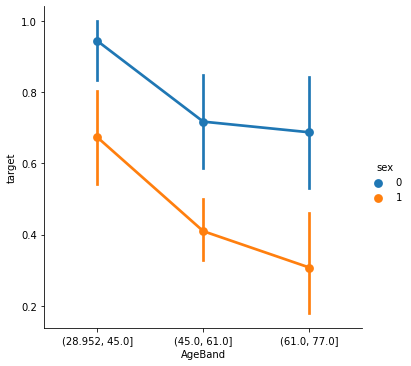

In [23]:
sns.factorplot('AgeBand','target',hue='sex',data=heart_data)
plt.show()

/opt/conda/lib/python3.7/site-packages/seaborn/categorical.py:3714: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)
/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


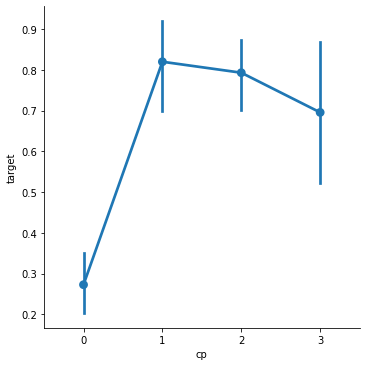

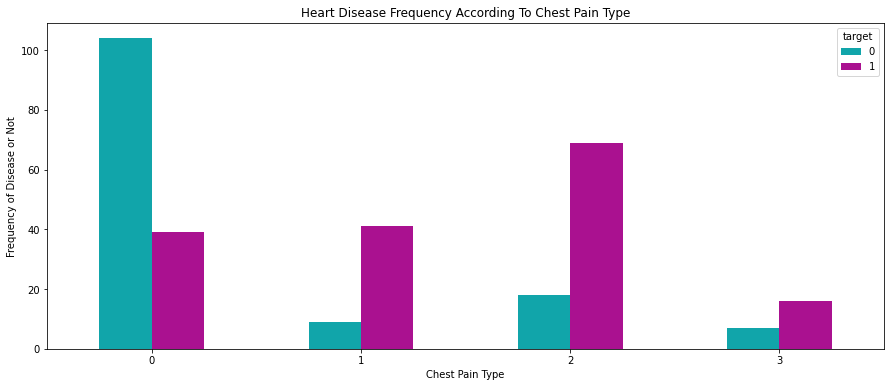

In [24]:
sns.factorplot('cp','target',data=heart_data)
pd.crosstab(heart_data.cp,heart_data.target).plot(kind="bar",figsize=(15,6),color=['#11A5AA','#AA1190' ])
plt.title('Heart Disease Frequency According To Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.xticks(rotation = 0)
plt.ylabel('Frequency of Disease or Not')
plt.show()

/opt/conda/lib/python3.7/site-packages/seaborn/categorical.py:3714: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)
/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


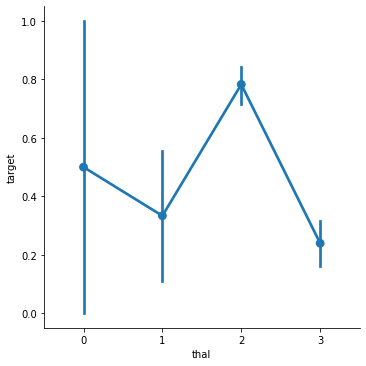

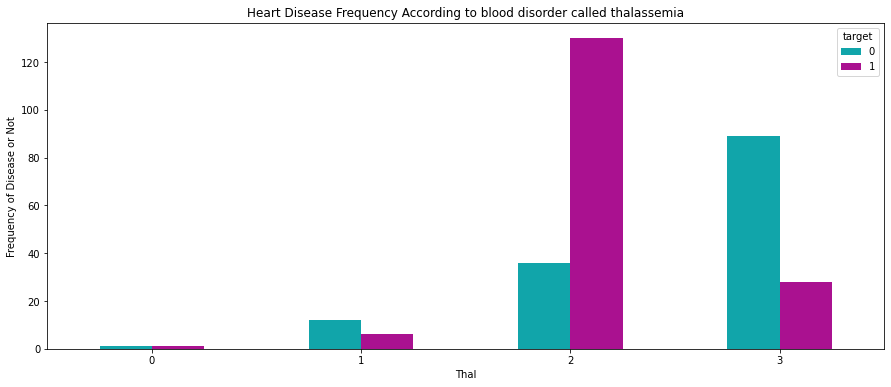

In [25]:
sns.factorplot('thal','target',data=heart_data)
pd.crosstab(heart_data.thal,heart_data.target).plot(kind="bar",figsize=(15,6),color=['#11A5AA','#AA1190' ])
plt.title('Heart Disease Frequency According to blood disorder called thalassemia')
plt.xlabel('Thal')
plt.xticks(rotation = 0)
plt.ylabel('Frequency of Disease or Not')
plt.show()

/opt/conda/lib/python3.7/site-packages/seaborn/categorical.py:3714: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)
/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


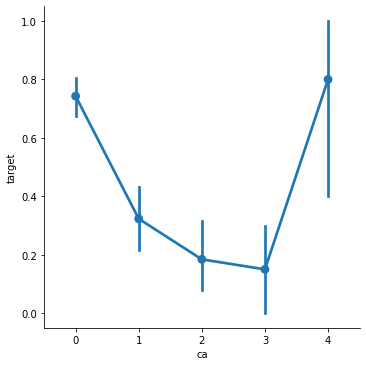

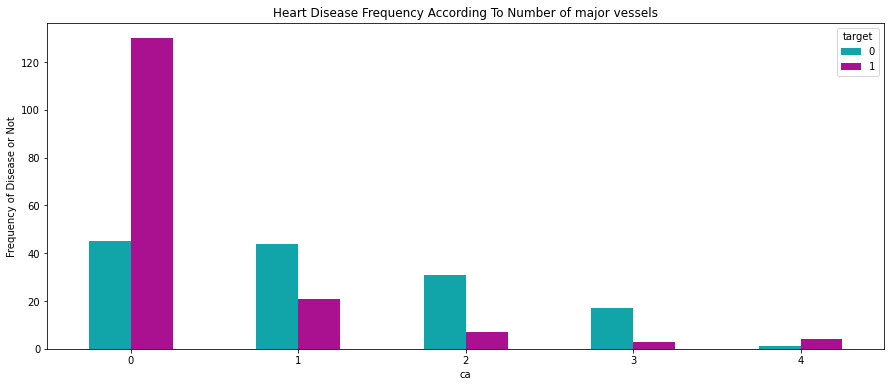

In [26]:
sns.factorplot('ca','target',data=heart_data)
pd.crosstab(heart_data.ca,heart_data.target).plot(kind="bar",figsize=(15,6),color=['#11A5AA','#AA1190' ])
plt.title('Heart Disease Frequency According To Number of major vessels')
plt.xlabel('ca')
plt.xticks(rotation = 0)
plt.ylabel('Frequency of Disease or Not')
plt.show()

/opt/conda/lib/python3.7/site-packages/seaborn/categorical.py:3714: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)
/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


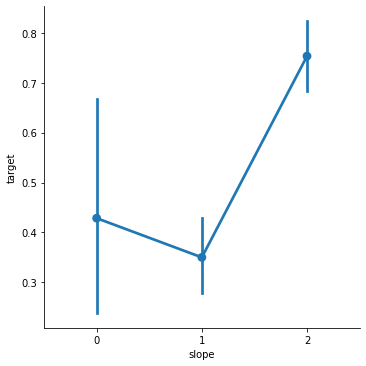

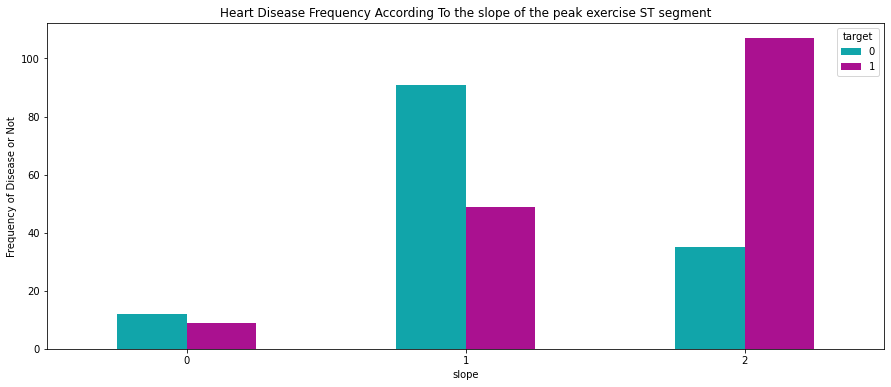

In [27]:
sns.factorplot('slope','target',data=heart_data)
pd.crosstab(heart_data.slope,heart_data.target).plot(kind="bar",figsize=(15,6),color=['#11A5AA','#AA1190' ])
plt.title('Heart Disease Frequency According To the slope of the peak exercise ST segment')
plt.xlabel('slope')
plt.xticks(rotation = 0)
plt.ylabel('Frequency of Disease or Not')
plt.show()

/opt/conda/lib/python3.7/site-packages/seaborn/categorical.py:3714: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)
/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


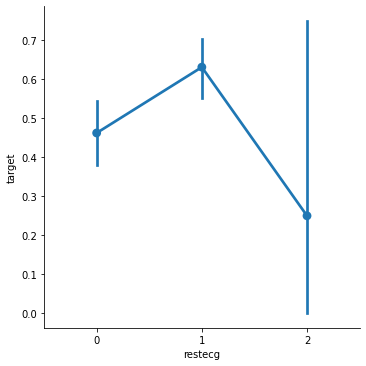

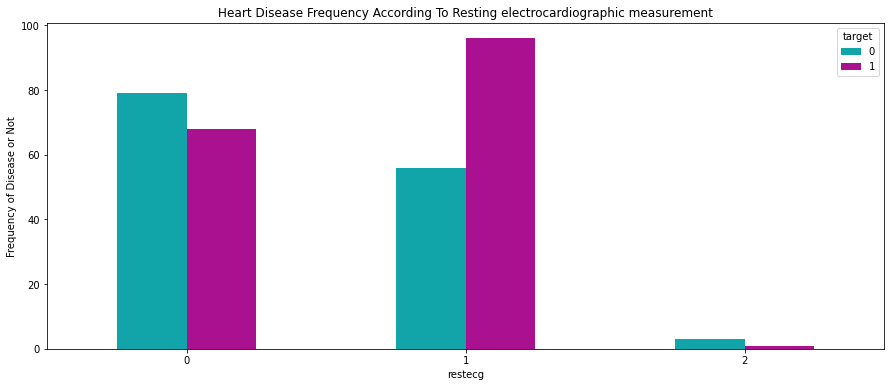

In [28]:
sns.factorplot('restecg','target',data=heart_data)
pd.crosstab(heart_data.restecg,heart_data.target).plot(kind="bar",figsize=(15,6),color=['#11A5AA','#AA1190' ])
plt.title('Heart Disease Frequency According To Resting electrocardiographic measurement')
plt.xlabel('restecg')
plt.xticks(rotation = 0)
plt.ylabel('Frequency of Disease or Not')
plt.show()

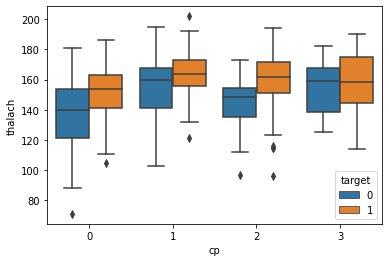

In [29]:
sns.boxplot(x='cp',y='thalach',hue='target',data=heart_data)
plt.show()

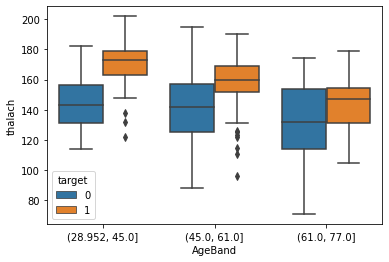

In [30]:
sns.boxplot(x='AgeBand',y='thalach',hue='target',data=heart_data)
plt.show()

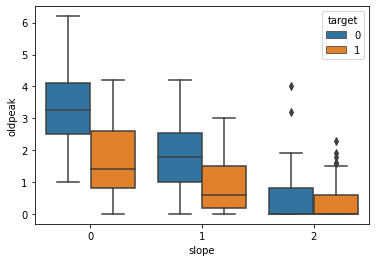

In [31]:
sns.boxplot(x='slope',y='oldpeak',hue='target',data=heart_data)
plt.show()

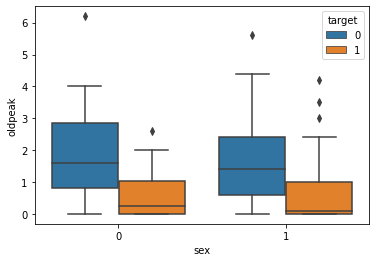

In [32]:
sns.boxplot(x='sex',y='oldpeak',hue='target',data=heart_data)
plt.show()

/opt/conda/lib/python3.7/site-packages/seaborn/categorical.py:3714: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)
/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


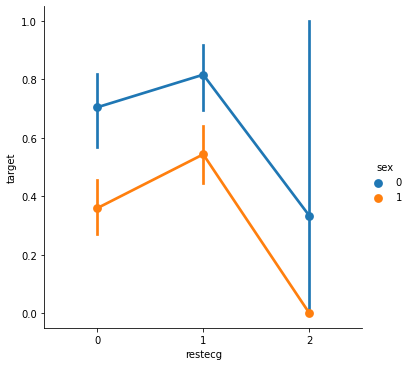

In [33]:
sns.factorplot('restecg','target',hue='sex',data=heart_data)
plt.show()

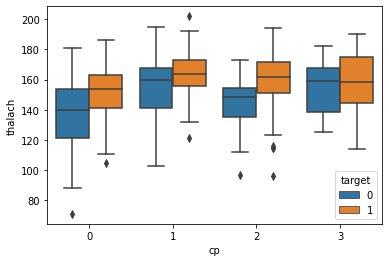

In [34]:
sns.boxplot(x='cp',y='thalach',hue='target',data=heart_data)
plt.show()

<AxesSubplot:>

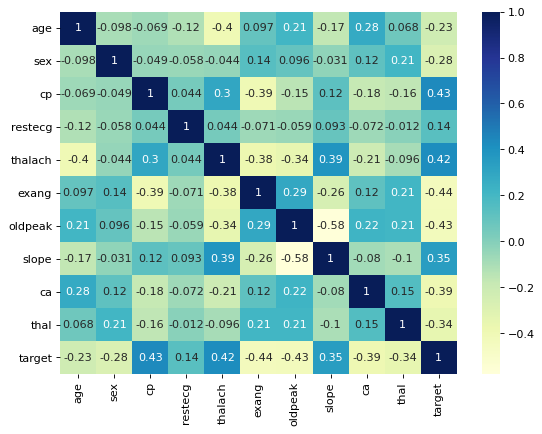

In [35]:
from matplotlib.pyplot import figure
figure(figsize=(8, 6), dpi=80)
corr=heart_data.corr()
sns.heatmap(corr,cmap="YlGnBu",annot = True)

# One Hot encoding

In [36]:
from sklearn.preprocessing import OneHotEncoder
one_hot_col=['cp','thal','restecg','ca','slope']
ohe = OneHotEncoder()
array_hot_encoded = ohe.fit_transform(heart_data[one_hot_col])
data_hot_encoded = pd.DataFrame(array_hot_encoded, index=heart_data.index)

In [37]:
data_hot_encoded=pd.get_dummies(heart_data, columns = one_hot_col)
#data_hot_encoded=data_hot_encoded.drop([one_hot_col],axis=1)

In [38]:
data_hot_encoded.columns

Index(['age', 'sex', 'thalach', 'exang', 'oldpeak', 'target', 'AgeBand',
       'cp_0', 'cp_1', 'cp_2', 'cp_3', 'thal_0', 'thal_1', 'thal_2', 'thal_3',
       'restecg_0', 'restecg_1', 'restecg_2', 'ca_0', 'ca_1', 'ca_2', 'ca_3',
       'ca_4', 'slope_0', 'slope_1', 'slope_2'],
      dtype='object')

In [39]:
drop_col=['AgeBand','cp_3','thal_0','restecg_2','ca_4','slope_0']
data_hot_encoded=data_hot_encoded.drop(drop_col,axis=1)
data_hot_encoded

,age,sex,thalach,exang,oldpeak,target,cp_0,cp_1,cp_2,thal_1,thal_2,thal_3,restecg_0,restecg_1,ca_0,ca_1,ca_2,ca_3,slope_1,slope_2
0,63,1,150,0,2.3,1,0,0,0,1,0,0,1,0,1,0,0,0,0,0
1,37,1,187,0,3.5,1,0,0,1,0,1,0,0,1,1,0,0,0,0,0
2,41,0,172,0,1.4,1,0,1,0,0,1,0,1,0,1,0,0,0,0,1
3,56,1,178,0,0.8,1,0,1,0,0,1,0,0,1,1,0,0,0,0,1
4,57,0,163,1,0.6,1,1,0,0,0,1,0,0,1,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,123,1,0.2,0,1,0,0,0,0,1,0,1,1,0,0,0,1,0
299,45,1,132,0,1.2,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0
300,68,1,141,0,3.4,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0
301,57,1,115,1,1.2,0,1,0,0,0,0,1,0,1,0,1,0,0,1,0


# Divide train/test

In [40]:
X=data_hot_encoded.drop('target',axis=1)
y=data_hot_encoded[['target']]

In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=1,
                                                   stratify=y)

In [42]:
#Convert to list
X_train=X_train.values
X_test=X_test.values
y_train=y_train.values
y_test=y_test.values

# Logistic

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier as rbf
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score,make_scorer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
from sklearn.metrics import f1_score
pipe = Pipeline([("scaler", StandardScaler()), ("logis", LogisticRegression())])
logis_param_grid = {
    'logis__l1_ratio':np.arange(0,1,0.05),
    'logis__C':np.arange(0,10,0.5),
'logis__class_weight':[dict,'balanced']}
grid = RandomizedSearchCV(pipe,param_distributions=logis_param_grid, cv=3,n_iter=50,scoring=make_scorer(accuracy_score)) 
grid.fit(X_train, y_train)

In [44]:
print(grid.best_params_)
print(grid.best_score_)

{'logis__l1_ratio': 0.55, 'logis__class_weight': 'balanced', 'logis__C': 1.0}
0.830114017437961


In [45]:
from sklearn.metrics import confusion_matrix,precision_score,recall_score
logis_pred=grid.predict(X_test)
# Making the Confusion Matrix
cm = confusion_matrix(y_test, logis_pred)
print ("Confusion Matrix:\n",cm)

# Accuracy, Precision and Recall
score1 = accuracy_score(y_test,logis_pred)
score2 = precision_score(y_test,logis_pred)
score3= recall_score(y_test,logis_pred)
print("\n")
print("Accuracy is ",round(score1*100,2),"%")
print("Precision is ",round(score2,2))
print("Recall is ",round(score3,2))

Confusion Matrix:
 [[36  5]
 [ 8 42]]


Accuracy is  85.71 %
Precision is  0.89
Recall is  0.84


In [ ]:
logis_model=LogisticRegression(l1_ratio=0.75,class_weight='balanced',C=1)
logis_model.fit(X_train,y_train)

In [47]:
logis_pred=logis_model.predict(X_test)
# Making the Confusion Matrix
cm = confusion_matrix(y_test, logis_pred)
print ("Confusion Matrix:\n",cm)

# Accuracy, Precision and Recall
score1 = accuracy_score(y_test,logis_pred)
score2 = precision_score(y_test,logis_pred)
score3= recall_score(y_test,logis_pred)
print("\n")
print("Accuracy is ",round(score1*100,2),"%")
print("Precision is ",round(score2,2))
print("Recall is ",round(score3,2))

Confusion Matrix:
 [[37  4]
 [ 7 43]]


Accuracy is  87.91 %
Precision is  0.91
Recall is  0.86


# Random Forest

In [ ]:
Coef_feature=pd.DataFrame(logis_model.coef_,columns=X.columns)

pipe_rf = make_pipeline(rbf())
rf_param_grid = {

    'randomforestclassifier__criterion':['gini','entropy'],
    'randomforestclassifier__max_features': ['auto','sqrt','log2',None],
    'randomforestclassifier__max_depth': np.arange(1,50,1),
    'randomforestclassifier__n_estimators': np.arange(1,200,5),
    'randomforestclassifier__min_weight_fraction_leaf': np.arange(0,0.5,0.05),
    'randomforestclassifier__min_samples_split':np.arange(1,50,1)
    
}

# Perform RandomizedSearchCV
randomized_search_rf = RandomizedSearchCV(estimator=pipe_rf,param_distributions=rf_param_grid,n_iter=50,scoring=make_scorer(accuracy_score),verbose=0,cv=4)
randomized_search_rf.fit(X_train,y_train)

In [51]:
print(randomized_search_rf.best_params_)
print(randomized_search_rf.best_score_)

{'randomforestclassifier__n_estimators': 16, 'randomforestclassifier__min_weight_fraction_leaf': 0.0, 'randomforestclassifier__min_samples_split': 45, 'randomforestclassifier__max_features': 'log2', 'randomforestclassifier__max_depth': 45, 'randomforestclassifier__criterion': 'gini'}
0.8301886792452831


In [52]:
randomized_search_rf=rbf(n_estimators=111,min_weight_fraction_leaf=0.15000000000000002,min_samples_split=35,max_features='auto',max_depth= 2,criterion='gini')
randomized_search_rf.fit(X_train,y_train)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:2: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  


RandomForestClassifier(max_depth=2, min_samples_split=35,
                       min_weight_fraction_leaf=0.15000000000000002,
                       n_estimators=111)

In [53]:
rf_pred=randomized_search_rf.predict(X_test)
# Making the Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)
print ("Confusion Matrix:\n",cm)

# Accuracy, Precision and Recall
score1 = accuracy_score(y_test,rf_pred)
score2 = precision_score(y_test,rf_pred)
score3= recall_score(y_test,rf_pred)
print("\n")
print("Accuracy is ",round(score1*100,2),"%")
print("Precision is ",round(score2,2))
print("Recall is ",round(score3,2))

Confusion Matrix:
 [[34  7]
 [ 6 44]]


Accuracy is  85.71 %
Precision is  0.86
Recall is  0.88


In [54]:
features=X.columns
importances = randomized_search_rf.feature_importances_
indices = np.argsort(importances)

Text(0.5, 0, 'Relative Importance')

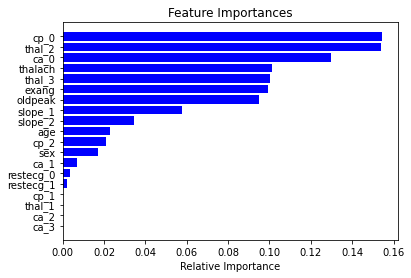

In [55]:
plt.figure(1)
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), features[indices])
plt.xlabel('Relative Importance')

# Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier as gbr
pipe_gbr=make_pipeline(gbr())
gbr_param_grid = {
    'gradientboostingclassifier__learning_rate':np.arange(0.1,2,0.1),
    'gradientboostingclassifier__max_features': ['auto','sqrt','log2',None],
    'gradientboostingclassifier__max_depth': np.arange(1,50,1),
    'gradientboostingclassifier__n_estimators': np.arange(1,200,5),
    'gradientboostingclassifier__min_weight_fraction_leaf': np.arange(0,0.5,0.05),
    'gradientboostingclassifier__min_samples_split':np.arange(1,50,1)
    
}

# Perform RandomizedSearchCV
randomized_search_gbr = RandomizedSearchCV(estimator=pipe_gbr,param_distributions=gbr_param_grid,n_iter=50,scoring=make_scorer(accuracy_score),verbose=1,cv=4)
randomized_search_gbr.fit(X_train, y_train)

In [57]:
print(randomized_search_gbr.best_params_)
print(randomized_search_gbr.best_score_)

{'gradientboostingclassifier__n_estimators': 6, 'gradientboostingclassifier__min_weight_fraction_leaf': 0.35000000000000003, 'gradientboostingclassifier__min_samples_split': 38, 'gradientboostingclassifier__max_features': 'auto', 'gradientboostingclassifier__max_depth': 19, 'gradientboostingclassifier__learning_rate': 0.4}
0.8113207547169812


In [ ]:
gbr_model=gbr(n_estimators=31,min_weight_fraction_leaf=0.4,min_samples_split=22,
              max_features=None,max_depth=36,learning_rate=0.1)
gbr_model.fit(X_train,y_train)

In [59]:
gbr_pred=gbr_model.predict(X_test)
# Making the Confusion Matrix
cm = confusion_matrix(y_test, gbr_pred)
print ("Confusion Matrix:\n",cm)

# Accuracy, Precision and Recall
score1 = accuracy_score(y_test,gbr_pred)
score2 = precision_score(y_test,gbr_pred)
score3= recall_score(y_test,gbr_pred)
score4 = f1_score(y_test,gbr_pred)
print("\n")
print("Accuracy is ",round(score1*100,2),"%")
print("Precision is ",round(score2,2))
print("Recall is ",round(score3,2))
print("F-measure is ",round(score4,2))

Confusion Matrix:
 [[35  6]
 [ 7 43]]


Accuracy is  85.71 %
Precision is  0.88
Recall is  0.86
F-measure is  0.87


In [60]:
features=X.columns
importances = gbr_model.feature_importances_
indices = np.argsort(importances)

Text(0.5, 0, 'Relative Importance')

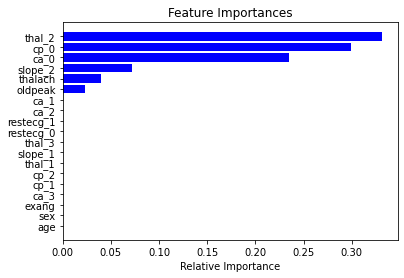

In [61]:
plt.figure(1)
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), features[indices])
plt.xlabel('Relative Importance')

# Naive Bayes

In [62]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train,y_train)

/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


GaussianNB()

In [63]:
nb_pred=nb.predict(X_test)
# Making the Confusion Matrix
cm = confusion_matrix(y_test,nb_pred)
print ("Confusion Matrix:\n",cm)

# Accuracy, Precision and Recall
score1 = accuracy_score(y_test,nb_pred)
score2 = precision_score(y_test,nb_pred)
score3= recall_score(y_test,nb_pred)
score4 = f1_score(y_test,nb_pred)
print("\n")
print("Accuracy is ",round(score1*100,2),"%")
print("Precision is ",round(score2,2))
print("Recall is ",round(score3,2))
print("F-measure is ",round(score4,2))

Confusion Matrix:
 [[34  7]
 [ 9 41]]


Accuracy is  82.42 %
Precision is  0.85
Recall is  0.82
F-measure is  0.84


# SVC

In [64]:
from sklearn.svm import SVC
svm = SVC(random_state = 1)
svm.fit(X_train, y_train)

/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


SVC(random_state=1)

In [65]:
svc_pred=svm.predict(X_test)
# Making the Confusion Matrix
cm = confusion_matrix(y_test,svc_pred)
print ("Confusion Matrix:\n",cm)

# Accuracy, Precision and Recall
score1 = accuracy_score(y_test,svc_pred)
score2 = precision_score(y_test,svc_pred)
score3= recall_score(y_test,svc_pred)
score4 = f1_score(y_test,svc_pred)
print("\n")
print("Accuracy is ",round(score1*100,2),"%")
print("Precision is ",round(score2,2))
print("Recall is ",round(score3,2))
print("F-measure is ",round(score4,2))

Confusion Matrix:
 [[24 17]
 [12 38]]


Accuracy is  68.13 %
Precision is  0.69
Recall is  0.76
F-measure is  0.72


# KNN

In [66]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors =3)  # n_neighbors means k
knn.fit(X_train, y_train)

/opt/conda/lib/python3.7/site-packages/sklearn/neighbors/_classification.py:179: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=3)

In [67]:
knn_pred=knn.predict(X_test)
# Making the Confusion Matrix
cm = confusion_matrix(y_test,knn_pred)
print ("Confusion Matrix:\n",cm)

# Accuracy, Precision and Recall
score1 = accuracy_score(y_test,knn_pred)
score2 = precision_score(y_test,knn_pred)
score3= recall_score(y_test,knn_pred)
score4 = f1_score(y_test,knn_pred)
print("\n")
print("Accuracy is ",round(score1*100,2),"%")
print("Precision is ",round(score2,2))
print("Recall is ",round(score3,2))
print("F-measure is ",round(score4,2))

Confusion Matrix:
 [[21 20]
 [16 34]]


Accuracy is  60.44 %
Precision is  0.63
Recall is  0.68
F-measure is  0.65
